In [1]:
%load_ext autoreload
%autoreload 2

# Random sampling

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R

In [5]:
ode = Trajectory1PAT1R()

min_p = ode._min_p
max_p = ode._max_p

min_logm = -1.0
max_logm = 10.0

min_chi1 = ode._min_chi1
max_chi1 = ode._max_chi1

min_chi2 = ode._min_chi2
max_chi2 = ode._max_chi2

N_TESTS = 2000
dt = 1.   # time step [s]
T  = 100    # total duration [yr]

In [6]:
logm1 = np.random.uniform(min_logm, max_logm, N_TESTS)
logm2 = np.random.uniform(min_logm, max_logm, N_TESTS)
m1 = np.array([10.**np.max([logm1[i], logm2[i]]) for i in range(N_TESTS)])
m2 = np.array([10.**np.min([logm1[i], logm2[i]]) for i in range(N_TESTS)])
nu = m1 * m2 / (m1 + m2)**2.
chi1 = np.random.uniform(min_chi1, max_chi1, N_TESTS)
chi2 = np.random.uniform(min_chi2, max_chi2, N_TESTS)

p = np.array([np.random.uniform(*ode.bounds_p(0.0, 1.0, chi1[i], p_buffer=[0.01,0.0])) for i in range(N_TESTS)])

theta = np.random.uniform(0, np.pi, N_TESTS)
phi   = np.random.uniform(0, 2*np.pi, N_TESTS)

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [7]:
failed_indices = []
for i in range(N_TESTS):
    try:
        WF1PAT1R = Waveform1PAT1R()
        h1PAT1R = WF1PAT1R(m1[i], m2[i], chi1[i], p[i], theta[i], phi[i], chi2[i], dt=dt, T=T)
    except ValueError as e:
        print(f"  -> ValueError at i={i}: {e}")
        failed_indices.append(i)

print(f"\nFailed indices: {failed_indices}")


Failed indices: []


In [10]:
mask = np.ones(N_TESTS, dtype=bool)
mask[failed_indices] = False

nu_failed = nu[~mask]
chi1_failed = chi1[~mask]
chi2_failed = chi2[~mask]
p_failed = p[~mask]

nu_success = nu[mask]
chi1_success = chi1[mask]
chi2_success = chi2[mask]
p_success = p[mask]

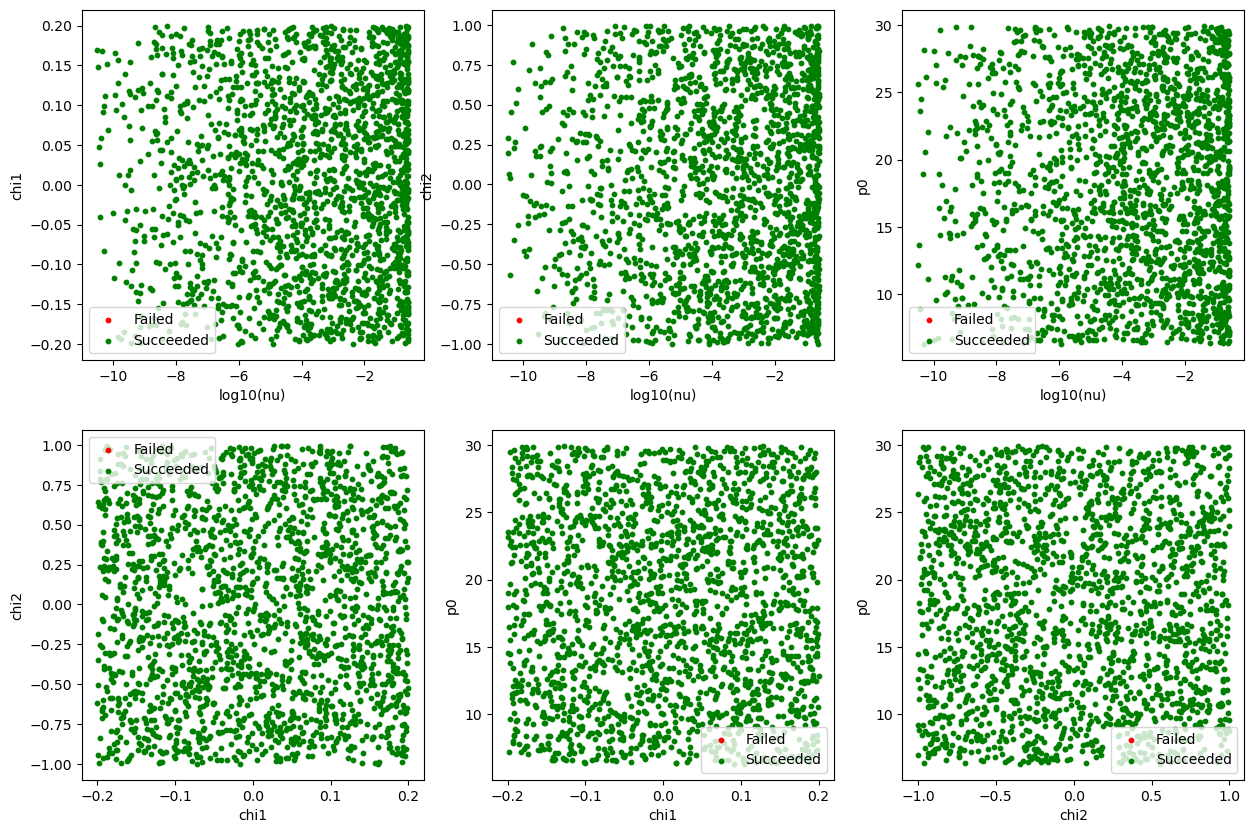

In [11]:
fig, axs = plt.subplots(2,3,figsize=(15,10))

axs[0,0].scatter(np.log10(nu_failed), chi1_failed, color='red', label='Failed', s=10)
axs[0,0].scatter(np.log10(nu_success), chi1_success, color='green', label='Succeeded', s=10)
axs[0,0].set_xlabel('log10(nu)')
axs[0,0].set_ylabel('chi1')
axs[0,0].legend()

axs[0,1].scatter(np.log10(nu_failed), chi2_failed, color='red', label='Failed', s=10)
axs[0,1].scatter(np.log10(nu_success), chi2_success, color='green', label='Succeeded', s=10)
axs[0,1].set_xlabel('log10(nu)')
axs[0,1].set_ylabel('chi2')
axs[0,1].legend()

axs[0,2].scatter(np.log10(nu_failed), p_failed, color='red', label='Failed', s=10)
axs[0,2].scatter(np.log10(nu_success), p_success, color='green', label='Succeeded', s=10)
axs[0,2].set_xlabel('log10(nu)')
axs[0,2].set_ylabel('p0')
axs[0,2].legend()

axs[1,0].scatter(chi1_failed, chi2_failed, color='red', label='Failed', s=10)
axs[1,0].scatter(chi1_success, chi2_success, color='green', label='Succeeded', s=10)
axs[1,0].set_xlabel('chi1')
axs[1,0].set_ylabel('chi2')
axs[1,0].legend()

axs[1,1].scatter(chi1_failed, p_failed, color='red', label='Failed', s=10)
axs[1,1].scatter(chi1_success, p_success, color='green', label='Succeeded', s=10)
axs[1,1].set_xlabel('chi1')
axs[1,1].set_ylabel('p0')
axs[1,1].legend()

axs[1,2].scatter(chi2_failed, p_failed, color='red', label='Failed', s=10)
axs[1,2].scatter(chi2_success, p_success, color='green', label='Succeeded', s=10)
axs[1,2].set_xlabel('chi2')
axs[1,2].set_ylabel('p0')
axs[1,2].legend()

plt.show()